# 同じバニラ面と異なる経路：Heston / local volatility

保存済み JSON / NPZ だけから、バニラ残差、二時点分布、固定月次 Asian の3図を表示します。
数値監査と採否の再計算は `build_reference.py --check` で行います。notebook は計算の再実行を行いません。

In [1]:
import importlib.util
import json
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib  # Japanese labels must not produce missing-glyph warnings.
from IPython.display import Markdown, display

get_ipython().run_line_magic("matplotlib", "inline")

def resolve_directory(variable, filename):
    supplied = os.environ.get(variable)
    candidates = [Path(supplied)] if supplied else [Path.cwd()]
    if not supplied:
        candidates += [parent / "johnhull/research/RB-F04"
                       for parent in [Path.cwd(), *Path.cwd().parents]]
    for candidate in candidates:
        if (candidate / filename).is_file():
            return candidate
    raise FileNotFoundError("Saved RB-F04 bundle or loader unavailable; set " + variable)

artifact_dir = resolve_directory("JOHNHULL_DYNAMICS_ARTIFACT_DIR", "reference.json")
source_dir = resolve_directory("JOHNHULL_DYNAMICS_SOURCE_DIR", "build_reference.py")
spec = importlib.util.spec_from_file_location("rbf04_saved_bundle", source_dir / "build_reference.py")
loader = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = loader
spec.loader.exec_module(loader)
# load_result restores the existing CAS blob when necessary; it performs no model run.
record, arrays = loader.load_result(artifact_dir)
protocol = record["protocol"]
levels = sorted(record["combined"]["levels"], key=lambda row: row["steps"])
finest = levels[-1]
two_date = finest["two_date"]
decision = record.get("decision", {})
status = decision.get("status", "decision_not_saved")
mode = record.get("mode", "main")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": False})

def numeric(value):
    return np.asarray(value, dtype=float)

def supported_estimate(summary):
    mean = numeric(summary.get("mean"))
    se = numeric(summary.get("standard_error"))
    supported = np.asarray(summary.get("supported", True), dtype=bool)
    valid = np.isfinite(mean) & np.isfinite(se) & supported
    return np.where(valid, mean, np.nan), np.where(valid, se, np.nan)

def value_text(value):
    return "unsupported" if value is None or not np.isfinite(value) else f"{value:.6g}"

cuts = numeric(protocol["two_date"]["bins"])
bin_labels = ([f"[-inf, {cuts[0]:g})"]
              + [f"[{left:g}, {right:g})" for left, right in zip(cuts[:-1], cuts[1:])]
              + [f"[{cuts[-1]:g}, +inf)"])
seed_ids = [row["seed"] for row in record.get("seeds", [])]
print("Saved-artifact mode:", mode, "| decision:", status)
print("Independent seeds:", ", ".join(str(seed) for seed in seed_ids))
print("Display only: no path generation, Fourier integration, PDE solve, learning, or network.")
contract = protocol["contract"]
display(Markdown(f"固定契約: 満期 {contract['expiry']:g} 年、strike {contract['asian_strike']:g}、"
                 f"正時点の月次 {len(contract['observations'])} 観測、初期spotを含める設定 "
                 f"`{contract['include_initial']}`。標本誤差CIは面構成・離散化の誤差を含みません。"))
if mode != "main":
    display(Markdown("**fixture / smoke: 合成表示確認であり、主実験の識別結果ではありません。**"))


Saved-artifact mode: main | decision: difference_not_identified
Independent seeds: 9017, 9029, 9047
Display only: no path generation, Fourier integration, PDE solve, learning, or network.


固定契約: 満期 1 年、strike 100、正時点の月次 12 観測、初期spotを含める設定 `False`。標本誤差CIは面構成・離散化の誤差を含みません。

## 1. バニラ再価格と面の支持領域

own independent CF と選択面の独立 PDE、各モデルの MC を比較します。通貨残差と標本SEを表示し、
NaN / 未支持領域を灰色、明示した wing 拡張の境界を破線で示します。有限quoteの確認は全面一致の証明ではありません。

Selected PDE: joint_refined


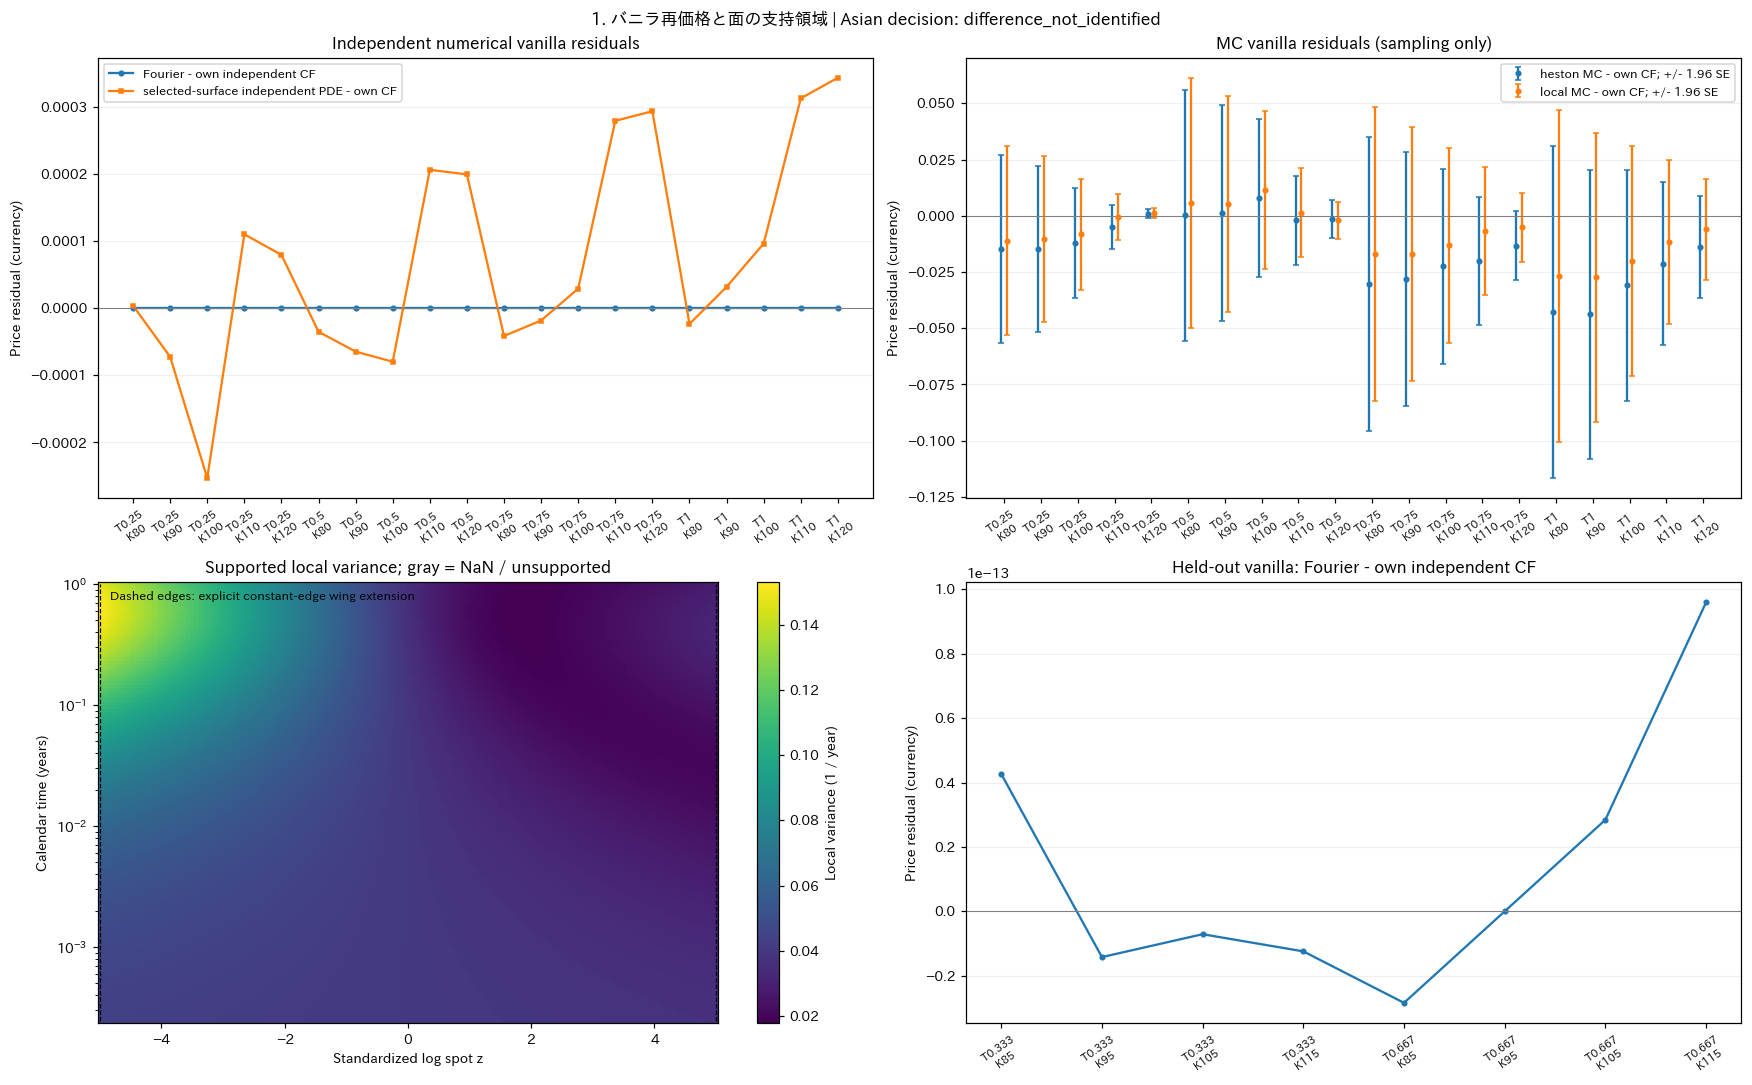

Surface unsupported / NaN nodes: 0 / 20769
Explicit wing boundaries (saved): [[  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]
 [  0 160]

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
times = arrays["reference.quotes.times"]
strikes = arrays["reference.quotes.strikes"]
fourier = arrays["reference.quotes.fourier"]
independent = arrays["reference.quotes.independent"]
positions = np.arange(len(times))
labels = [f"T{time:g}\nK{strike:g}" for time, strike in zip(times, strikes)]
axes[0, 0].plot(positions, fourier - independent, "o-", markersize=3,
               label="Fourier - own independent CF")
selected = protocol.get("freeze", {}).get("selected_surface")
selected_prefix = f"pilot.surface_pde.{selected}"
matched_pde = False
if selected is not None and selected_prefix + ".price" in arrays:
    prefix = selected_prefix
    pde_times = arrays.get(prefix + ".quote_times", [])
    pde_strikes = arrays.get(prefix + ".quote_strikes", [])
    pde_price = arrays[prefix + ".price"]
    pde_supported = arrays.get(prefix + ".supported", np.ones_like(pde_price, dtype=bool))
    residual = np.full(len(times), np.nan)
    for index, (time, strike) in enumerate(zip(times, strikes)):
        matches = np.flatnonzero(np.isclose(pde_times, time) & np.isclose(pde_strikes, strike))
        if len(matches) == 1 and bool(pde_supported[matches[0]]):
            residual[index] = pde_price[matches[0]] - independent[index]
    if np.isfinite(residual).any():
        axes[0, 0].plot(positions, residual, "s-", markersize=3,
                       label="selected-surface independent PDE - own CF")
        matched_pde = True
        print("Selected PDE:", selected)
if not matched_pde:
    axes[0, 0].text(.02, .97, "Selected PDE quote arrays unavailable / unsupported",
                    transform=axes[0, 0].transAxes, va="top")
for model, color, offset in [("heston", "tab:blue", -.08), ("local", "tab:orange", .08)]:
    mean, se = supported_estimate(finest["vanilla"][model])
    mean, se = mean.ravel(), se.ravel()
    if len(mean) != len(independent):
        raise ValueError("Saved vanilla summary and quote grid disagree")
    axes[0, 1].errorbar(positions + offset, mean - independent, yerr=1.96 * se,
                       fmt="o", capsize=2, markersize=3, color=color,
                       label=model + " MC - own CF; +/- 1.96 SE")
for ax, title in zip(axes[0], ["Independent numerical vanilla residuals", "MC vanilla residuals (sampling only)"]):
    ax.axhline(0, color="gray", linewidth=.7)
    ax.set_xticks(positions, labels, fontsize=7, rotation=35)
    ax.set_ylabel("Price residual (currency)")
    ax.set_title(title)
    ax.grid(axis="y", alpha=.2)
    ax.legend(fontsize=8)
surface_times = arrays["surface.times"]
z_nodes = arrays["surface.z_nodes"]
variance = arrays["surface.local_variance"]
supported = np.asarray(arrays["surface.supported"], dtype=bool) & np.isfinite(variance)
cmap = plt.get_cmap("viridis").copy()
cmap.set_bad("lightgray")
image = axes[1, 0].pcolormesh(z_nodes, surface_times, np.ma.masked_where(~supported, variance),
                             shading="auto", cmap=cmap)
fig.colorbar(image, ax=axes[1, 0], label="Local variance (1 / year)")
axes[1, 0].set_title("Supported local variance; gray = NaN / unsupported")
axes[1, 0].set_xlabel("Standardized log spot z")
axes[1, 0].set_ylabel("Calendar time (years)")
axes[1, 0].set_yscale("log")
wing_indices = np.asarray(arrays["surface.wing_boundaries"], dtype=int)
if wing_indices.shape != (len(surface_times), 2) or np.any(wing_indices < 0) or np.any(wing_indices >= len(z_nodes)):
    raise ValueError("Saved wing boundary indices are invalid")
wing_z = z_nodes[wing_indices]
for side in range(2):
    axes[1, 0].plot(wing_z[:, side], surface_times, color="black", linestyle="--", linewidth=.8)
axes[1, 0].text(.02, .98, "Dashed edges: explicit constant-edge wing extension",
                transform=axes[1, 0].transAxes, va="top", fontsize=8)
hold_times = arrays["reference.holdouts.times"]
hold_strikes = arrays["reference.holdouts.strikes"]
hold_residual = arrays["reference.holdouts.fourier"] - arrays["reference.holdouts.independent"]
axes[1, 1].plot(np.arange(len(hold_times)), hold_residual, "o-", markersize=3)
axes[1, 1].axhline(0, color="gray", linewidth=.7)
axes[1, 1].set_xticks(np.arange(len(hold_times)),
                      [f"T{time:.3g}\nK{strike:g}" for time, strike in zip(hold_times, hold_strikes)],
                      fontsize=7, rotation=35)
axes[1, 1].set_title("Held-out vanilla: Fourier - own independent CF")
axes[1, 1].set_ylabel("Price residual (currency)")
axes[1, 1].grid(axis="y", alpha=.2)
fig.suptitle("1. バニラ再価格と面の支持領域 | Asian decision: " + status, fontsize=11)
fig.tight_layout()
plt.show()
plt.close(fig)
print("Surface unsupported / NaN nodes:", int((~supported).sum()), "/", supported.size)
print("Explicit wing boundaries (saved):", arrays.get("surface.wing_boundaries", "not saved"))
print("Row-specific wing z boundaries:", wing_z.tolist())
print("Finite quotes and held-out checks do not establish equality of the whole vanilla surface.")


## 2. 二時点分布と各モデル固有の条件付き分母

両側の尾部を含むbinで joint 差と paired SE、条件付き確率と差の標本区間を表示します。
条件付き分母は各モデルの第1時点bin件数です。低件数binは unsupported とし、経路失敗を除外して比較しません。

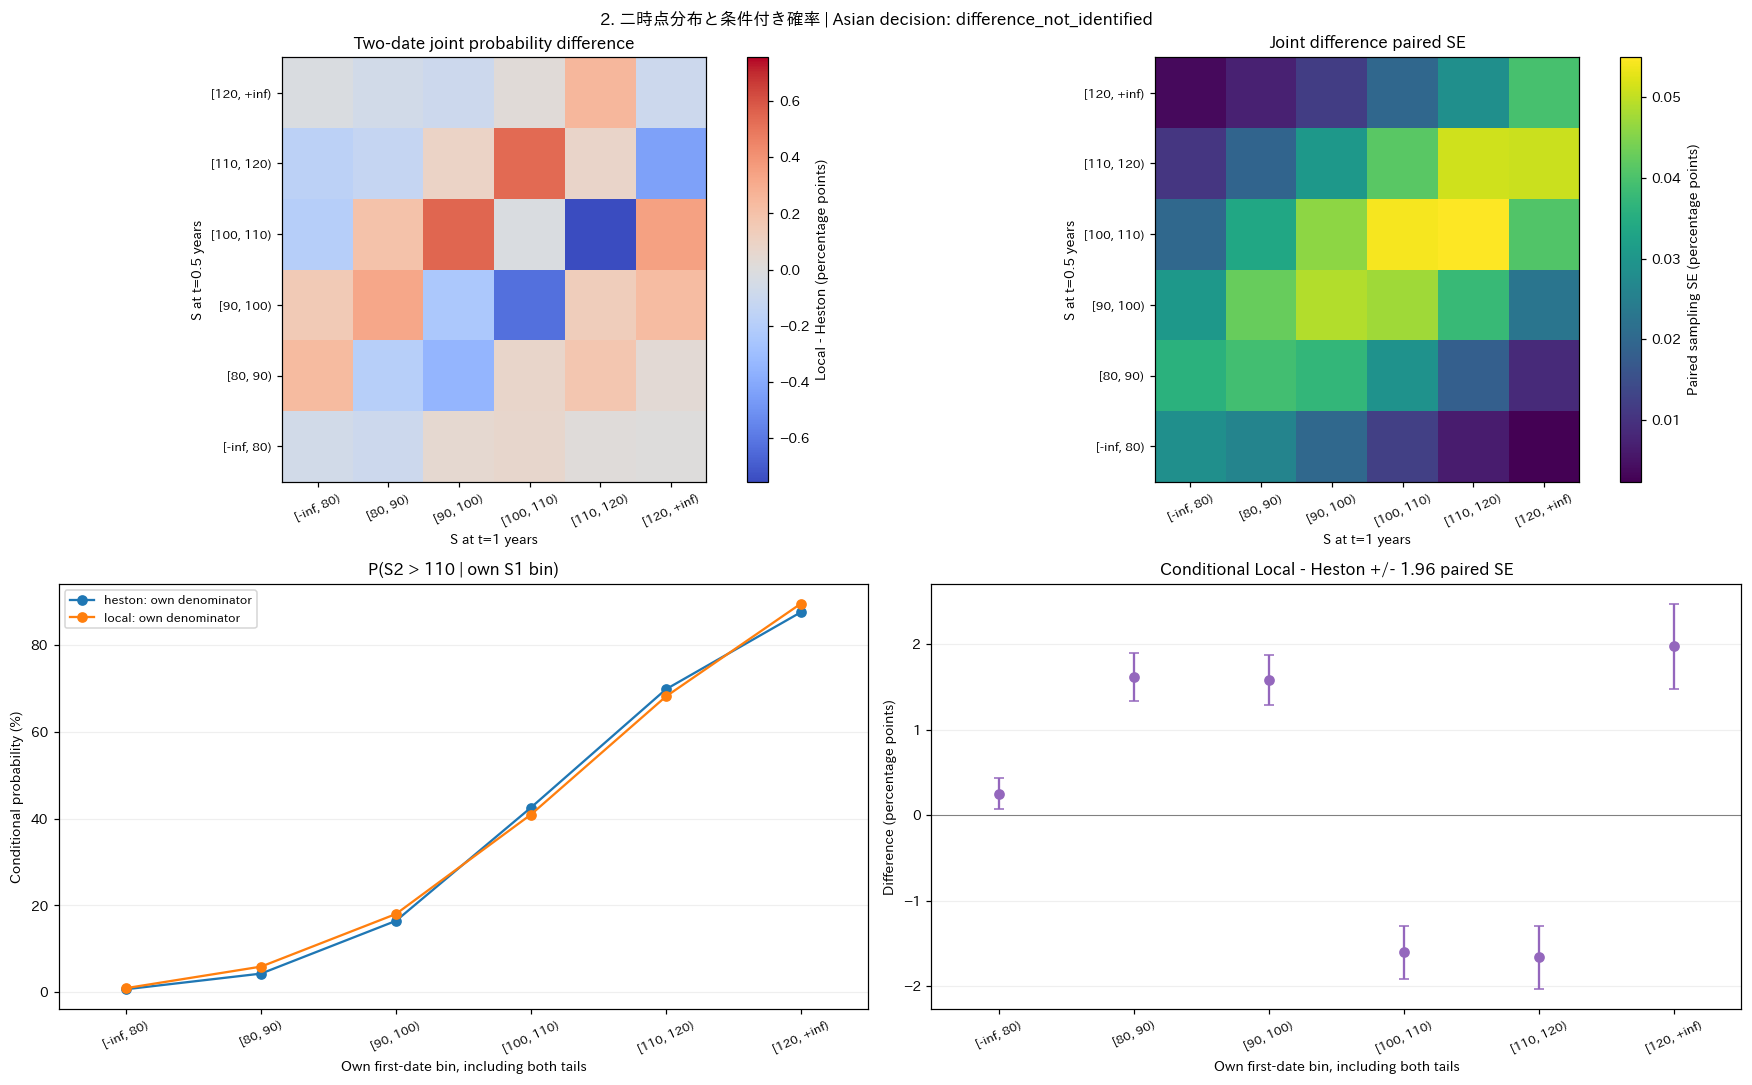

Tail-inclusive bins: [-inf, 80); [80, 90); [90, 100); [100, 110); [110, 120); [120, +inf)
Own conditional denominators: heston=[14040, 25074, 45474, 56200, 40489, 15331]; local=[14005, 25006, 45408, 56422, 40430, 15337]
Low-count bins unsupported: []
Joint / conditional difference uses paired SE; denominator sets may differ between models.
Zero observed joint count / SE does not establish probability zero; bin intervals are pointwise descriptive.
Failed path pairs retained: 0


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
joint_difference = numeric(two_date["joint_difference"]) * 100
joint_se = numeric(two_date["joint_standard_error"]) * 100
if not two_date.get("supported", False):
    joint_difference[:] = np.nan
    joint_se[:] = np.nan
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad("lightgray")
finite_joint = np.abs(joint_difference[np.isfinite(joint_difference)])
limit = max(float(finite_joint.max()) if len(finite_joint) else 0, 1e-12)
image = axes[0, 0].imshow(np.ma.masked_invalid(joint_difference), origin="lower", cmap=cmap,
                           vmin=-limit, vmax=limit)
fig.colorbar(image, ax=axes[0, 0], label="Local - Heston (percentage points)")
axes[0, 0].set_title("Two-date joint probability difference")
image = axes[0, 1].imshow(np.ma.masked_invalid(joint_se), origin="lower", cmap="viridis")
fig.colorbar(image, ax=axes[0, 1], label="Paired sampling SE (percentage points)")
axes[0, 1].set_title("Joint difference paired SE")
for ax in axes[0]:
    ax.set_xticks(range(len(bin_labels)), bin_labels, rotation=25, fontsize=8)
    ax.set_yticks(range(len(bin_labels)), bin_labels, fontsize=8)
    ax.set_xlabel(f"S at t={protocol['two_date']['second']:g} years")
    ax.set_ylabel(f"S at t={protocol['two_date']['first']:g} years")
positions = np.arange(len(bin_labels))
conditional_supported = np.asarray(two_date["conditional_supported"], dtype=bool)
for model, color in [("heston", "tab:blue"), ("local", "tab:orange")]:
    probabilities = numeric(two_date["conditional_" + model]) * 100
    axes[1, 0].plot(positions, np.where(conditional_supported, probabilities, np.nan),
                    "o-", color=color, label=model + ": own denominator")
axes[1, 0].set_title(f"P(S2 > {protocol['two_date']['conditional_threshold']:g} | own S1 bin)")
axes[1, 0].set_ylabel("Conditional probability (%)")
axes[1, 0].legend(fontsize=8)
difference = numeric(two_date["conditional_difference"]) * 100
se = numeric(two_date["conditional_standard_error"]) * 100
valid = conditional_supported & np.isfinite(difference) & np.isfinite(se)
axes[1, 1].errorbar(positions[valid], difference[valid], yerr=1.96 * se[valid],
                   fmt="o", color="tab:purple", capsize=3)
axes[1, 1].axhline(0, color="gray", linewidth=.7)
axes[1, 1].set_title("Conditional Local - Heston +/- 1.96 paired SE")
axes[1, 1].set_ylabel("Difference (percentage points)")
for ax in axes[1]:
    ax.set_xticks(positions, bin_labels, rotation=25, fontsize=8)
    ax.set_xlim(-.5, len(bin_labels) - .5)
    ax.set_xlabel("Own first-date bin, including both tails")
    ax.grid(axis="y", alpha=.2)
    for position in positions[~valid]:
        ax.text(position, .02, "unsupported", rotation=90, ha="center", va="bottom",
                transform=ax.get_xaxis_transform(), color="gray", fontsize=8)
fig.suptitle("2. 二時点分布と条件付き確率 | Asian decision: " + status, fontsize=11)
fig.tight_layout()
plt.show()
plt.close(fig)
print("Tail-inclusive bins:", "; ".join(bin_labels))
print("Own conditional denominators: heston=" + str(two_date['conditional_counts_heston'])
      + "; local=" + str(two_date['conditional_counts_local']))
print("Low-count bins unsupported:", [label for label, valid in zip(bin_labels, conditional_supported) if not valid])
print("Joint / conditional difference uses paired SE; denominator sets may differ between models.")
print("Zero observed joint count / SE does not establish probability zero; bin intervals are pointwise descriptive.")
print("Failed path pairs retained:", two_date.get("failed_pairs", "not saved"))


## 3. Asian の差と誤差の種類

標本誤差は約95%の 1.96 SE、離散化は粗細経路を結合した経験的差です。面/PDE診断を別に表示します。
経験的refinementは厳密boundではなく、vanilla PDE残差をAsianの誤差限界として足し合わせません。精度予算未設定なら判断はpendingです。

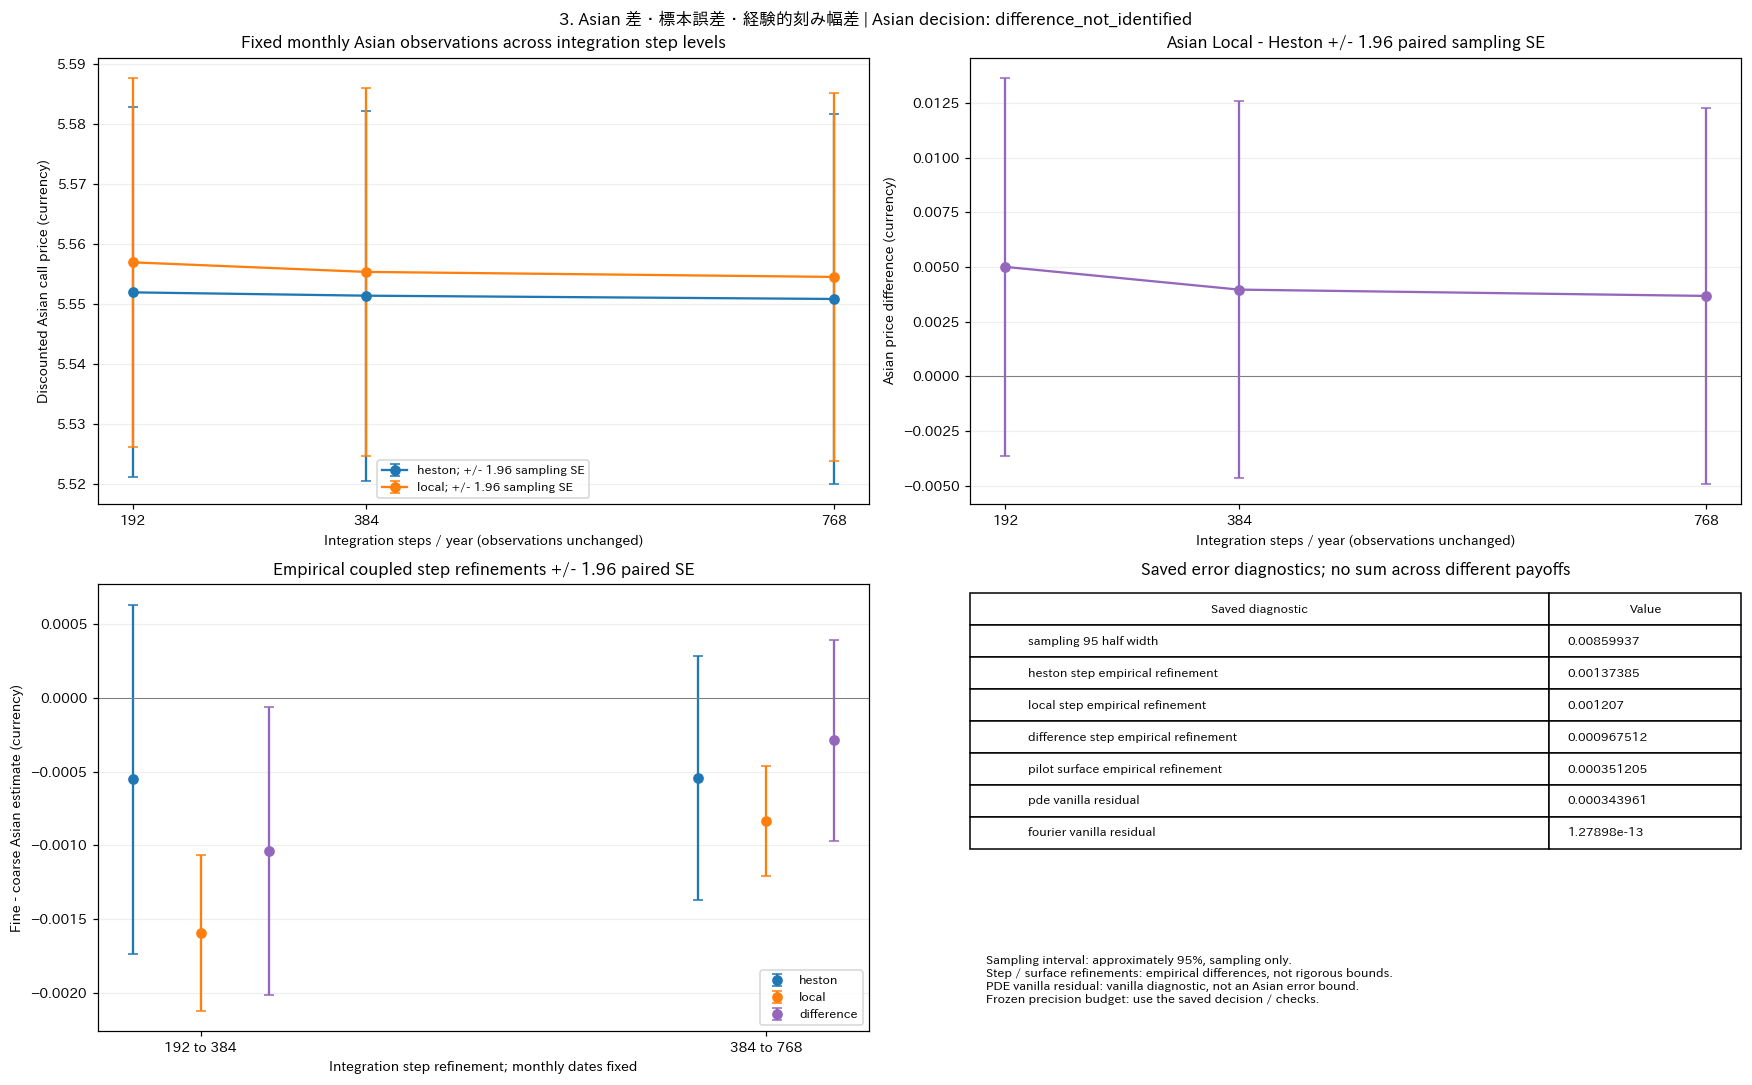

Asian difference: 0.00367288 ; paired sampling SE: 0.00438743
Decision from saved record: difference_not_identified
Frozen precision checks: {"fourier_vanilla_residual": true, "heston_step_empirical_refinement": true, "local_step_empirical_refinement": true, "pde_vanilla_residual": true, "pilot_surface_empirical_refinement": true, "sampling_95_half_width": true, "vanilla_mc_guard": true}
Empirical identification threshold (currency): 0.0115314
Saved path / surface diagnostics: {"heston": {"failed_paths": 0, "negative_variance_states": 2096, "surface_visited_paths": {}, "surface_visits": {}}, "local": {"failed_paths": 0, "negative_variance_states": 0, "surface_visited_paths": {"initial_state": 196608, "interior": 196608, "wing_left": 779}, "surface_visits": {"initial_state": 196608, "interior": 150737844, "wing_left": 60492}}}


**保存された判断: `difference_not_identified`。** Asian差の絶対値は、標本誤差と経験的refinementの固定識別閾値を超えませんでした。 経験的識別閾値（通貨）: 0.0115314。 単一時点quoteの数値整合性と経路依存価格の識別は別に評価します。合成・固定パラメータの結果を市場でのモデル順位へ外挿しません。

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
steps = np.asarray([level["steps"] for level in levels])
for model, color in [("heston", "tab:blue"), ("local", "tab:orange")]:
    summaries = [supported_estimate(level["asian"][model]) for level in levels]
    means = numeric([item[0].item() for item in summaries])
    ses = numeric([item[1].item() for item in summaries])
    axes[0, 0].errorbar(steps, means, yerr=1.96 * ses, fmt="o-", color=color,
                       capsize=3, label=model + "; +/- 1.96 sampling SE")
axes[0, 0].set_title("Fixed monthly Asian observations across integration step levels")
axes[0, 0].set_ylabel("Discounted Asian call price (currency)")
axes[0, 0].legend(fontsize=8)
summaries = [supported_estimate(level["asian"]["difference"]) for level in levels]
means = numeric([item[0].item() for item in summaries])
ses = numeric([item[1].item() for item in summaries])
axes[0, 1].errorbar(steps, means, yerr=1.96 * ses, fmt="o-", color="tab:purple", capsize=3)
axes[0, 1].axhline(0, color="gray", linewidth=.7)
axes[0, 1].set_title("Asian Local - Heston +/- 1.96 paired sampling SE")
axes[0, 1].set_ylabel("Asian price difference (currency)")
changes = record["combined"].get("step_changes", [])
change_positions = np.arange(len(changes))
for name, color, offset in [("heston_asian", "tab:blue", -.12),
                             ("local_asian", "tab:orange", 0),
                             ("difference_asian", "tab:purple", .12)]:
    summaries = [supported_estimate(change[name]) for change in changes if name in change]
    if len(summaries) == len(changes) and summaries:
        values = numeric([item[0].item() for item in summaries])
        errors = numeric([item[1].item() for item in summaries])
        axes[1, 0].errorbar(change_positions + offset, values, yerr=1.96 * errors,
                           fmt="o", color=color, capsize=3, label=name.replace("_asian", ""))
axes[1, 0].axhline(0, color="gray", linewidth=.7)
axes[1, 0].set_xticks(change_positions,
                      [f"{change['coarse']} to {change['fine']}"
                       for change in changes])
axes[1, 0].set_title("Empirical coupled step refinements +/- 1.96 paired SE")
axes[1, 0].set_ylabel("Fine - coarse Asian estimate (currency)")
axes[1, 0].set_xlabel("Integration step refinement; monthly dates fixed")
if changes:
    axes[1, 0].legend(fontsize=8)
components = decision.get("error_components", {})
axes[1, 1].set_axis_off()
axes[1, 1].set_title("Saved error diagnostics; no sum across different payoffs")
rows = [(key.replace("_", " "), value_text(value)) for key, value in components.items()
        if isinstance(value, (int, float)) or value is None]
table = axes[1, 1].table(cellText=rows or [["Error components", "not saved"]],
                        colLabels=["Saved diagnostic", "Value"], loc="upper center",
                        cellLoc="left", colWidths=[.75, .25])
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)
budget_note = ("Precision budget absent from saved protocol."
               if protocol.get("numerical_precision") is None
               else "Frozen precision budget: use the saved decision / checks.")
axes[1, 1].text(.02, .06,
                "Sampling interval: approximately 95%, sampling only.\n"
                "Step / surface refinements: empirical differences, not rigorous bounds.\n"
                "PDE vanilla residual: vanilla diagnostic, not an Asian error bound.\n"
                + budget_note,
                transform=axes[1, 1].transAxes, va="bottom", fontsize=8)
for ax in axes[0]:
    ax.set_xlabel("Integration steps / year (observations unchanged)")
    ax.set_xticks(steps)
for ax in [*axes[0], axes[1, 0]]:
    ax.grid(axis="y", alpha=.2)
fig.suptitle("3. Asian 差・標本誤差・経験的刻み幅差 | Asian decision: " + status, fontsize=11)
fig.tight_layout()
plt.show()
plt.close(fig)
mean, se = supported_estimate(finest["asian"]["difference"])
print("Asian difference:", value_text(mean.item()), "; paired sampling SE:", value_text(se.item()))
print("Decision from saved record:", status)
print("Frozen precision checks:", json.dumps(decision.get("precision_checks", {}), sort_keys=True))
threshold_text = value_text(decision.get("empirical_identification_threshold"))
print("Empirical identification threshold (currency):", threshold_text)
explanation = {
    "difference_identified": "Asian差の絶対値が、標本誤差と経験的refinementの固定識別閾値を超えました。",
    "difference_not_identified": "Asian差の絶対値は、標本誤差と経験的refinementの固定識別閾値を超えませんでした。",
    "numerical_precision_insufficient": "固定した精度検査をすべて満たしていないため、モデル差の識別を保留します。",
    "unsupported_paths": "未支持の経路を保持し、モデル差の識別を保留します。",
    "pending_precision_budget": "精度予算が未設定のため、モデル差の識別を保留します。",
}.get(status, "保存された状態と精度検査を確認してください。")
print("Saved path / surface diagnostics:", json.dumps(finest.get("diagnostics", {}), ensure_ascii=False, sort_keys=True))
display(Markdown(f"**保存された判断: `{status}`。** "
                 f"{explanation} 経験的識別閾値（通貨）: {threshold_text}。 "
                 "単一時点quoteの数値整合性と経路依存価格の識別は別に評価します。"
                 "合成・固定パラメータの結果を市場でのモデル順位へ外挿しません。"))
